<a href="https://colab.research.google.com/github/lucianoyllarreta/CLASE_CIENCIA_DATOS_I/blob/main/LOS%204%20FANT%C3%81STICOS/%20SCORING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
upload  = files.upload()

Saving df_final.csv to df_final.csv


In [3]:
import pandas as pd
df = pd.read_csv('df_final.csv')

In [14]:
df

,country,year,iso_code,population,gdp,gdp_per_capita,income_top10,income_bottom50,Female_15+,Male_15+,Total_15+,brecha de desempleo de genero,BCI
0,Afghanistan,1991,AFG,12238879,1.204736e+10,984.35,41.94,17.17,10.470,7.460,7.972,-3.010,2.442632
1,Afghanistan,1992,AFG,13278983,1.267754e+10,954.71,41.94,17.17,10.456,7.448,7.958,-3.008,2.442632
2,Afghanistan,1993,AFG,14943175,9.834582e+09,658.13,41.94,17.17,10.403,7.402,7.908,-3.001,2.442632
3,Afghanistan,1994,AFG,16250800,7.919856e+09,487.35,41.94,17.17,10.380,7.382,7.883,-2.998,2.442632
4,Afghanistan,1995,AFG,17065837,1.230753e+10,721.18,41.94,17.17,10.369,7.371,7.868,-2.998,2.442632
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5394,Zimbabwe,2020,ZWE,15526887,2.317871e+10,1492.81,58.95,9.23,8.491,8.744,8.617,0.253,6.386782
5395,Zimbabwe,2021,ZWE,15797220,2.514009e+10,1591.42,58.95,9.23,9.858,9.221,9.540,-0.637,6.386782
5396,Zimbabwe,2022,ZWE,16069061,2.590159e+10,1611.89,58.95,9.23,10.562,9.615,10.087,-0.947,6.386782
5397,Zimbabwe,2023,ZWE,16340829,NaN,NaN,58.95,9.23,9.516,9.182,9.348,-0.334,6.386782


In [18]:
print("PASO 4 — Construcción de KPIs")
print("=" * 60)

# KPI 1: Brecha de Concentración de Ingresos (BCI)
# Cuanto más alta → más desigualdad → peor score
df["BCI"] = df["income_top10"] / df["income_bottom50"]



print("  ✔ BCI creado             (income_top10 / income_bottom50)")
print(f"\n  BCI promedio global:  {df['BCI'].mean():.2f}")

PASO 4 — Construcción de KPIs
  ✔ BCI creado             (income_top10 / income_bottom50)

  BCI promedio global:  3.82


In [23]:
# Normalizar — nota la INVERSIÓN de lógica para variables donde
# "más alto = peor":
#   gdp_per_capita  → más alto = mejor  → sin invertir
#   unemp_total_15  → más alto = peor   → invertir (1 - norm)
#   BCI             → más alto = peor   → invertir (1 - norm)
print("PASO 5 — Normalización Min-Max (escala global histórica)")
print("=" * 60)

def minmax(series):
    """Normaliza una serie al rango [0, 1]."""
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(0.5, index=series.index)
    return (series - min_v) / (max_v - min_v)

df["norm_gdp"]    =       minmax(df["gdp_per_capita"])
df["norm_unemp"]  = 1   - minmax(df["Total_15+"])   # invertido
df["norm_bci"]    = 1   - minmax(df["BCI"])              # invertido

print("  ✔ norm_gdp     (mayor = mejor capacidad fiscal)")
print("  ✔ norm_unemp   (menor desempleo = mayor puntaje)")
print("  ✔ norm_bci     (menor concentración = mayor puntaje)")

PASO 5 — Normalización Min-Max (escala global histórica)
  ✔ norm_gdp     (mayor = mejor capacidad fiscal)
  ✔ norm_unemp   (menor desempleo = mayor puntaje)
  ✔ norm_bci     (menor concentración = mayor puntaje)


In [59]:
# 6. CÁLCULO DEL ÍNDICE DE RESILIENCIA (0-100)
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("PASO 6 — Índice de Resiliencia Macro-Social (0–100)")
print("=" * 60)

PESO_ECONOMICO  = 0.50
PESO_LABORAL    = 0.30
PESO_EQUIDAD    = 0.20

df["score_resiliencia"] = (
    df["norm_gdp"]   * PESO_ECONOMICO  +
    df["norm_unemp"] * PESO_LABORAL    +
    df["norm_bci"]   * PESO_EQUIDAD
) * 100

# Redondear a 2 decimales
df["score_resiliencia"] = df["score_resiliencia"].round(2)

print(f"  Pesos: Económico={PESO_ECONOMICO*100:.0f}% | "
      f"Laboral={PESO_LABORAL*100:.0f}% | Equidad={PESO_EQUIDAD*100:.0f}%")
print(f"\n  Score global promedio: {df['score_resiliencia'].mean():.1f}")
print(f"  Score mínimo:          {df['score_resiliencia'].min():.1f}")
print(f"  Score máximo:          {df['score_resiliencia'].max():.1f}")


PASO 6 — Índice de Resiliencia Macro-Social (0–100)
  Pesos: Económico=50% | Laboral=30% | Equidad=20%

  Score global promedio: 45.4
  Score mínimo:          16.8
  Score máximo:          95.1


In [57]:
print('Top 5 países ÚNICOS con los registros históricos más bajos de resiliencia:')
# Agrupar por país para obtener su peor momento histórico (mínimo score)
df_peores_unicos = df.groupby('country')[['year', 'score_resiliencia']].min().sort_values(by='score_resiliencia', ascending=True).head(5)
display(df_peores_unicos)

Top 5 países ÚNICOS con los registros históricos más bajos de resiliencia:


,year,score_resiliencia
country,,
North Macedonia,1991,11.30
South Africa,1991,13.71
Algeria,1991,17.63
Namibia,1991,18.99
Montenegro,1991,19.40


In [28]:
from IPython.display import display
top_5_gdp = df.sort_values(by='norm_gdp', ascending=False).head(5)
display(top_5_gdp[['country', 'year', 'norm_gdp']])

,country,year,norm_gdp
4065,Qatar,2011,1.000000
4066,Qatar,2012,0.994480
4067,Qatar,2013,0.984885
4068,Qatar,2014,0.950486
4069,Qatar,2015,0.909855


In [44]:
print('Top 15 por norm_gdp:')
top_15_gdp = df.sort_values(by='norm_gdp', ascending=False).head(15)
display(top_15_gdp[['country', 'year', 'norm_gdp']])

Top 15 por norm_gdp:


,country,year,norm_gdp
4065,Qatar,2011,1.000000
4066,Qatar,2012,0.994480
4067,Qatar,2013,0.984885
4068,Qatar,2014,0.950486
4069,Qatar,2015,0.909855
4070,Qatar,2016,0.875585
4064,Qatar,2010,0.853473
4071,Qatar,2017,0.828149
4072,Qatar,2018,0.821833
4073,Qatar,2019,0.816595


In [45]:
print('\nTop 15 por norm_unemp:')
top_15_unemp = df.sort_values(by='norm_unemp', ascending=False).head(15)
display(top_15_unemp[['country', 'year', 'norm_unemp']])


Top 15 por norm_unemp:


,country,year,norm_unemp
4073,Qatar,2019,1.000000
4072,Qatar,2018,0.999742
844,Cambodia,2019,0.999509
843,Cambodia,2018,0.999251
4077,Qatar,2023,0.999225
4076,Qatar,2022,0.999225
4078,Qatar,2024,0.999225
4074,Qatar,2020,0.998966
4071,Qatar,2017,0.998966
4075,Qatar,2021,0.998966


In [34]:
print('\nTop 15 por norm_bci:')
top_15_bci = df.sort_values(by='norm_bci', ascending=False).head(15)
display(top_15_bci[['country', 'year', 'norm_bci']])


Top 15 por norm_bci:


,country,year,norm_bci
4487,Slovenia,1991,1.000000
3705,Norway,1991,0.999884
2210,Hungary,1991,0.998738
3706,Norway,1992,0.998568
4454,Slovakia,1992,0.998224
4488,Slovenia,1992,0.997392
2214,Hungary,1995,0.995735
4455,Slovakia,1993,0.995528
1735,Finland,1992,0.995136
4858,Tajikistan,1991,0.995033


In [35]:
df_2020 = df[df['year'] == 2020]
display(df_2020[['country', 'score_resiliencia']])

,country,score_resiliencia
29,Afghanistan,49.37
63,Albania,52.29
97,Algeria,49.04
131,Angola,40.66
165,Argentina,50.51
...,...,...
5258,Uzbekistan,55.35
5292,Vanuatu,NaN
5326,Yemen,39.12
5360,Zambia,48.04


In [36]:
print('Top 20 países con mejor score de resiliencia en 2020:')
top_20_best = df_2020.sort_values(by='score_resiliencia', ascending=False).head(20)
display(top_20_best[['country', 'score_resiliencia']])

Top 20 países con mejor score de resiliencia en 2020:


,country,score_resiliencia
4074,Qatar,84.64
3734,Norway,76.50
4448,Singapore,72.04
5190,United Arab Emirates,70.78
4853,Switzerland,70.51
2409,Ireland,67.74
3530,Netherlands,67.55
2952,Luxembourg,66.73
1933,Germany,66.39
1355,Denmark,66.22


In [50]:
print('\nTop 20 países con peor score de resiliencia en 2020:')
top_20_worst = df_2020.sort_values(by='score_resiliencia', ascending=True).head(20)
display(top_20_worst[['country', 'score_resiliencia']])


Top 20 países con peor score de resiliencia en 2020:


,country,score_resiliencia
4618,South Africa,26.08
3462,Namibia,33.50
1389,Djibouti,35.24
1185,Costa Rica,36.99
1083,Colombia,37.08
1151,Congo,37.22
675,Botswana,37.55
4176,Saint Lucia,38.81
5326,Yemen,39.12
131,Angola,40.66


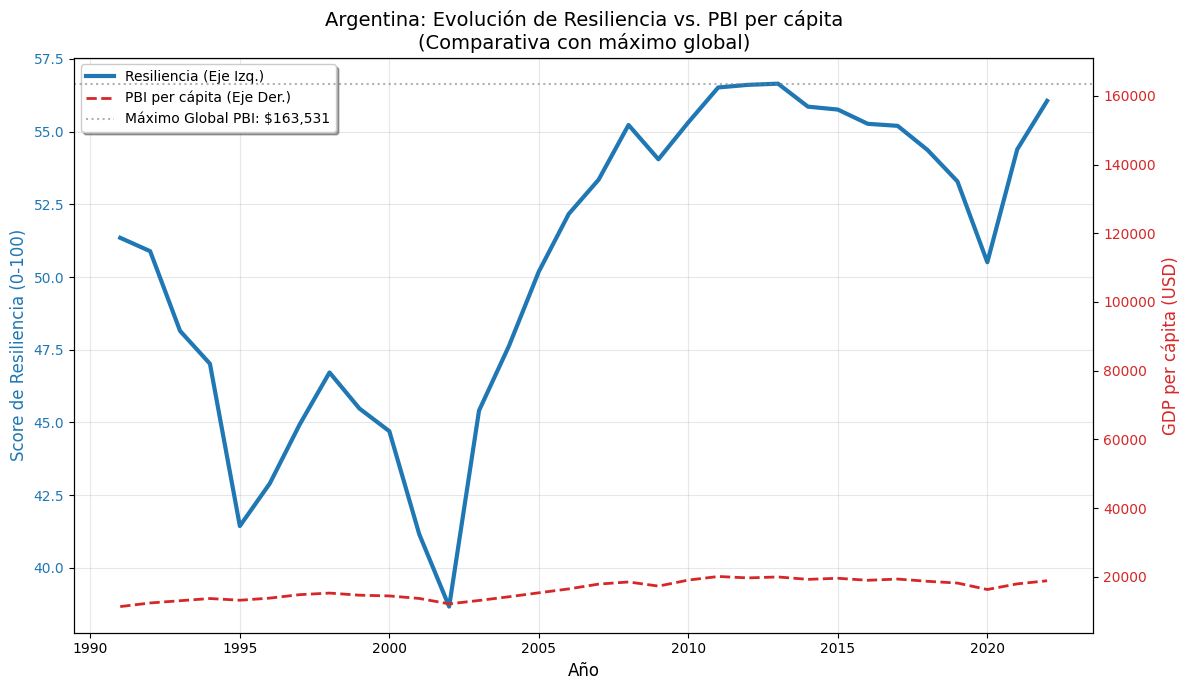

In [39]:
import matplotlib.pyplot as plt

# Filtrar datos para Argentina y ordenar por año
df_arg = df[df['country'] == 'Argentina'].sort_values('year')
global_max_gdp = df['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje 1: Score de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Score de Resiliencia (0-100)', color=color_res, fontsize=12)
lns1 = ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia (Eje Izq.)')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje 2: PBI per cápita
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita (USD)', color=color_pbi, fontsize=12)
lns2 = ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita (Eje Der.)')

# Referencia del máximo global
lns3 = ax2.axhline(y=global_max_gdp, color='gray', linestyle=':', alpha=0.6, label=f'Máximo Global PBI: ${global_max_gdp:,.0f}')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Combinar leyendas
lns = lns1 + lns2 + [lns3]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita\n(Comparativa con máximo global)', fontsize=14)
fig.tight_layout()
plt.show()

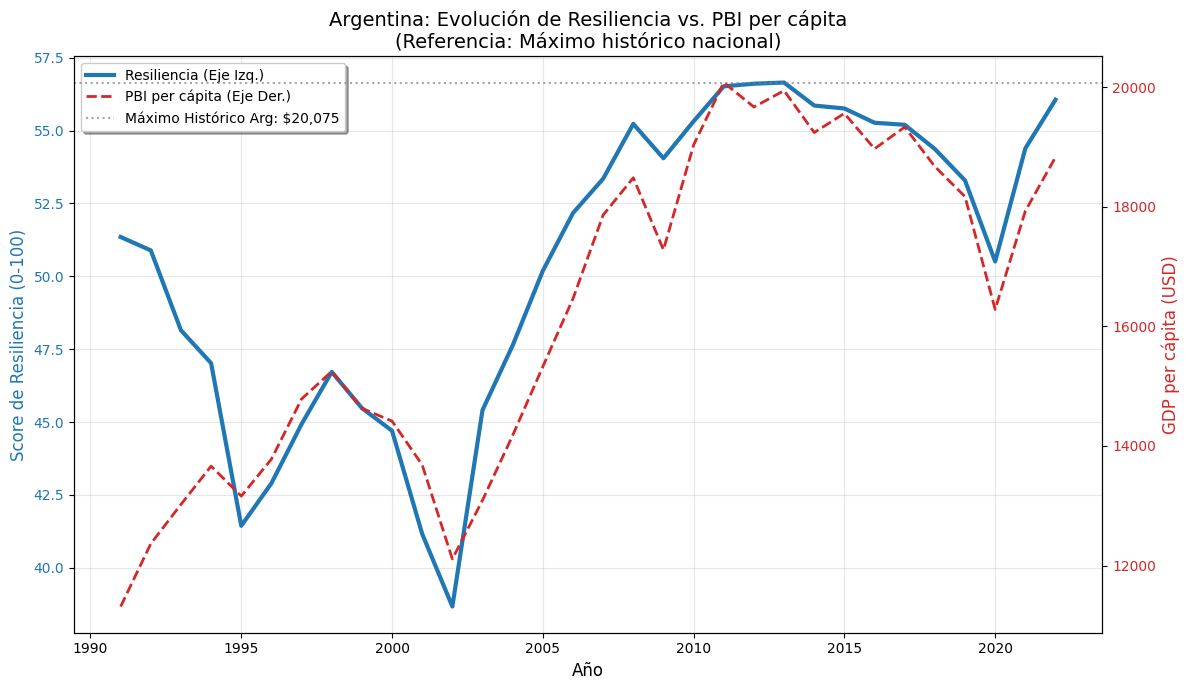

In [41]:
import matplotlib.pyplot as plt

# Filtrar datos para Argentina y ordenar por año
df_arg = df[df['country'] == 'Argentina'].sort_values('year')

# Calcular el máximo histórico de PBI específicamente para Argentina
arg_max_gdp = df_arg['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje 1: Score de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Score de Resiliencia (0-100)', color=color_res, fontsize=12)
lns1 = ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia (Eje Izq.)')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje 2: PBI per cápita
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita (USD)', color=color_pbi, fontsize=12)
lns2 = ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita (Eje Der.)')

# Referencia del máximo HISTÓRICO DE ARGENTINA
lns3 = ax2.axhline(y=arg_max_gdp, color='gray', linestyle=':', alpha=0.7, label=f'Máximo Histórico Arg: ${arg_max_gdp:,.0f}')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Combinar leyendas
lns = lns1 + lns2 + [lns3]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita\n(Referencia: Máximo histórico nacional)', fontsize=14)
fig.tight_layout()
plt.show()

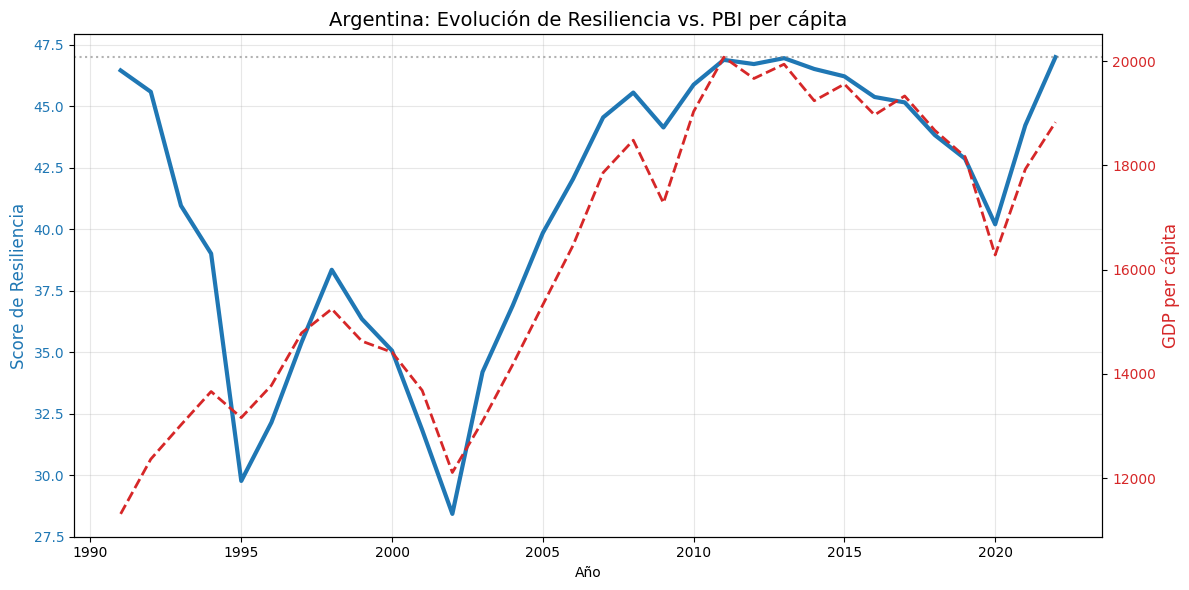

In [52]:
import matplotlib.pyplot as plt

# Filtrar datos de Argentina
df_arg = df[df['country'] == 'Argentina'].sort_values('year')
arg_max_gdp = df_arg['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Score de Resiliencia', color=color_res, fontsize=12)
ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje de PBI
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita', color=color_pbi, fontsize=12)
ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Línea de referencia del máximo nacional
ax2.axhline(y=arg_max_gdp, color='gray', linestyle=':', alpha=0.6, label=f'Máximo Arg: ${arg_max_gdp:,.0f}')

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita', fontsize=14)
fig.tight_layout()
plt.show()

### Análisis Histórico: Países de la ex-Yugoslavia
En esta sección analizamos la evolución del Índice de Resiliencia para las naciones que conformaron Yugoslavia, permitiendo comparar sus trayectorias de recuperación y estabilidad.

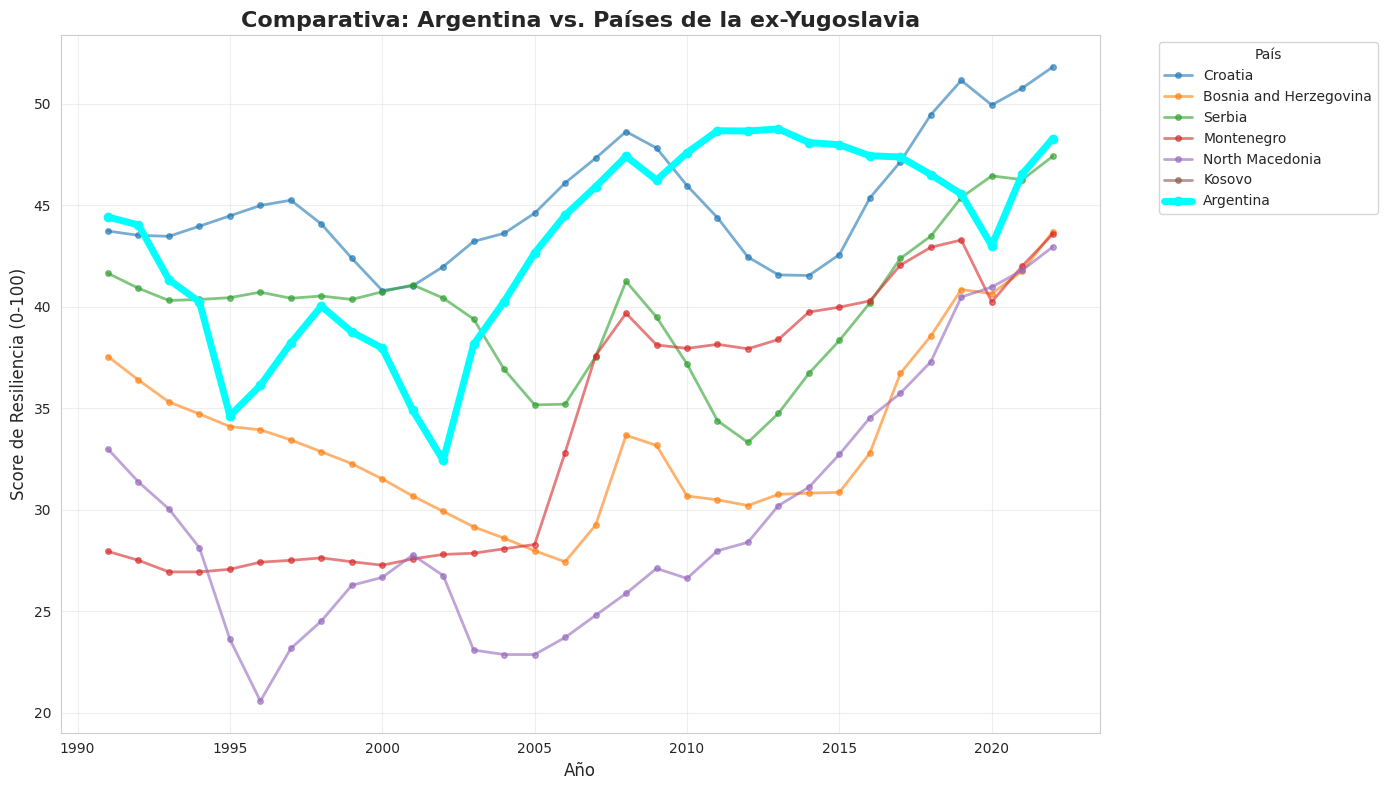

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de países solicitada (ex-Yugoslavia sin Eslovenia + Argentina)
paises_analisis = [
    'Croatia', 'Bosnia and Herzegovina', 'Serbia',
    'Montenegro', 'North Macedonia', 'Kosovo', 'Argentina'
]

# Filtrar el DataFrame
df_comp = df[df['country'].isin(paises_analisis)].sort_values(['country', 'year'])

# Configuración del gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Definir paleta: Argentina destacada, el resto en tonos grises/atenuados
# O usamos un color llamativo para Argentina
colores = {}
for p in paises_analisis:
    if p == 'Argentina':
        colores[p] = '#00FFFF' # Cyan brillante para destacar
    else:
        colores[p] = None # Dejar que seaborn asigne el resto

# Dibujar líneas
for pais in paises_analisis:
    data_p = df_comp[df_comp['country'] == pais]
    linewidth = 5 if pais == 'Argentina' else 2
    zorder = 10 if pais == 'Argentina' else 2
    alpha = 1.0 if pais == 'Argentina' else 0.6

    plt.plot(data_p['year'], data_p['score_resiliencia'],
             label=pais, linewidth=linewidth, zorder=zorder, alpha=alpha,
             marker='o', markersize=4 if pais != 'Argentina' else 6,
             color=colores[pais])

# Personalización
plt.title('Comparativa: Argentina vs. Países de la ex-Yugoslavia', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Score de Resiliencia (0-100)', fontsize=12)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Como podemos observar, países como **Eslovenia** suelen liderar la región debido a su temprana integración económica y estabilidad laboral, mientras que otros como **Macedonia del Norte** muestran los niveles históricos más bajos en los registros de la década de los 90.